Tournament rows available: 7894
Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Training rows : 6770  (2003-2022)
Test rows     : 391   (Season 2023)
Class balance (train) -- Wins: 50.1%  |  Losses: 49.9%

Scaler means  (train): {'DIFF_EFG': np.float64(-2e-05), 'Diff_TOV': np.float64(-0.03825), 'DIFF_ORB': np.float64(-0.00302), 'DIFF_FTR': np.float64(-0.00332)}
Scaler stdevs (train): {'DIFF_EFG': np.float64(0.1186), 'Diff_TOV': np.float64(7.37766), 'DIFF_ORB': np.float64(0.26773), 'DIFF_FTR': np.float64(0.21681)}

Model trained successfully.
Converged in 10 iterations.
Accuracy  : 0.926  (92.6%)
Log-Loss  : 0.1748
Benchmark : 0.6930  (coin flip)
Target    : < 0.60
Status    : P

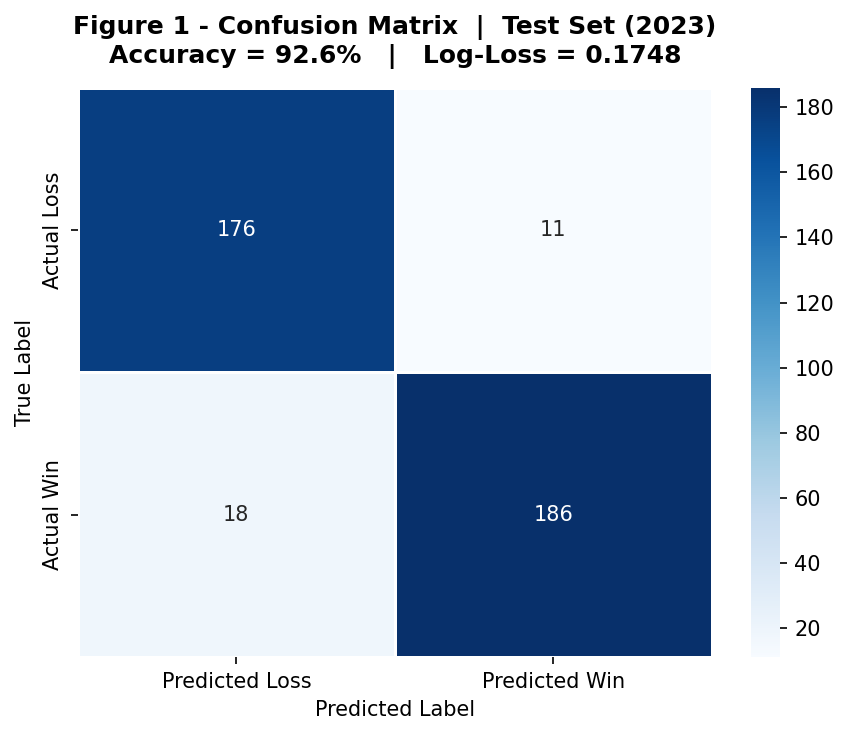

True Positives  (correct wins predicted)      : 186
True Negatives  (correct losses predicted)    : 176
False Positives (predicted win, actually lost): 11
False Negatives (predicted loss, actually won): 18

Logistic Regression Coefficients (after Z-score scaling)
 Feature  Coefficient
DIFF_EFG     6.473676
DIFF_ORB     2.572221
DIFF_FTR     1.932099
Diff_TOV    -2.670365

Intercept (bias): -0.0706

Full Model Equation:
log-odds(Win) = -0.0706 + 6.4737*DIFF_EFG - 2.6704*Diff_TOV + 2.5722*DIFF_ORB + 1.9321*DIFF_FTR
Then:  P(Win) = 1 / (1 + exp(-log_odds))

Odds Ratios (e^beta) per 1 standard deviation increase:
  DIFF_EFG      beta = +6.4737   odds ratio = 647.8611
  Diff_TOV      beta = -2.6704   odds ratio = 0.0692
  DIFF_ORB      beta = +2.5722   odds ratio = 13.0949
  DIFF_FTR      beta = +1.9321   odds ratio = 6.9040


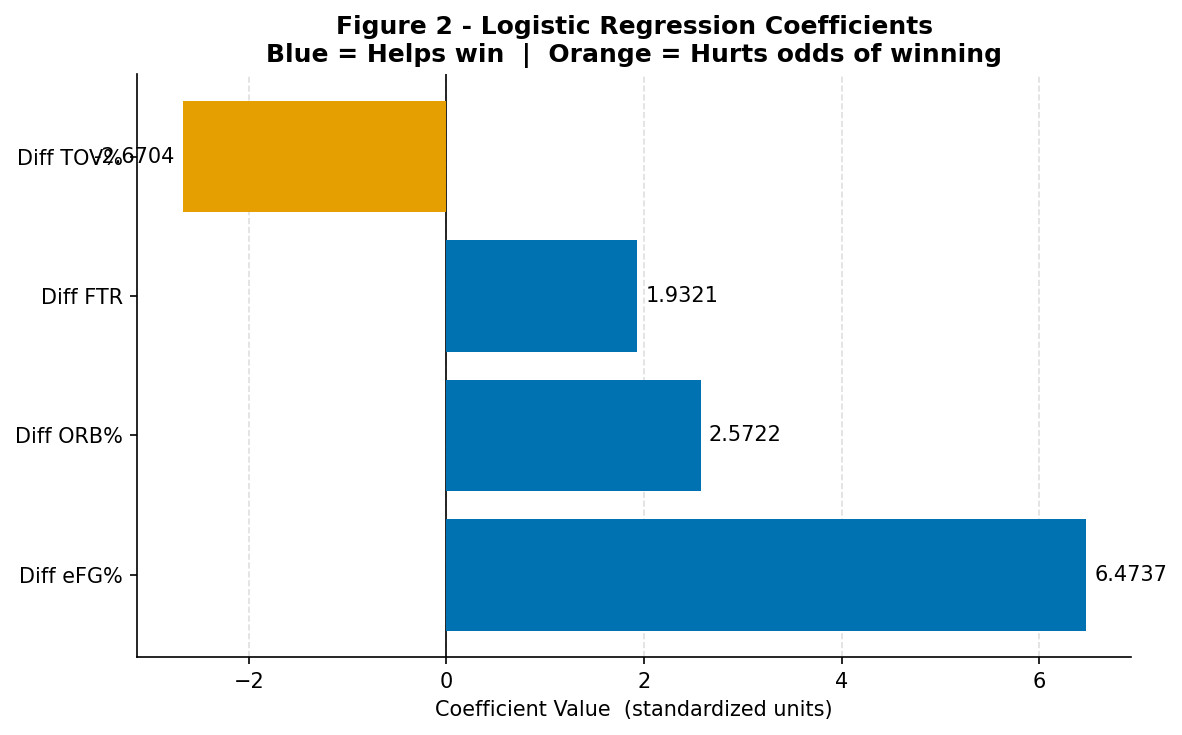

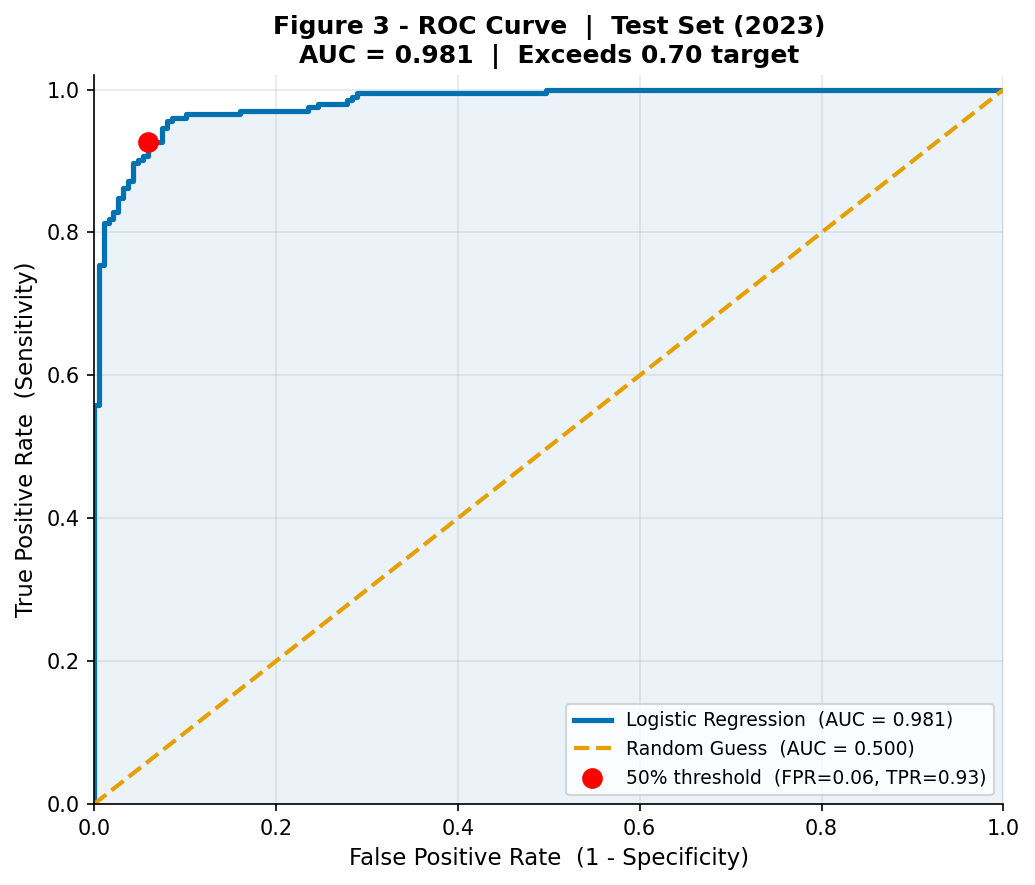

AUC Score : 0.9810
Target    : > 0.70
Status    : PASS
Exported predictions.csv -- 391 rows

Sample (top 5 most confident predictions):
 Season  TeamA_ID  TeamB_ID  Win_A  Pred_Prob_Win  Pred_Win  Correct
   2023      1242      1411      1            1.0         1        1
   2023      1222      1331      1            1.0         1        1
   2023      1112      1394      1            1.0         1        1
   2023      1397      1280      1            1.0         1        1
   2023      1116      1421      1            1.0         1        1


In [ ]:
# ECE 3308 Project 3: Building the Brain (Logistic Regression)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    roc_curve, roc_auc_score
)


#
# Section 1: Loads all of the data
#

#Loads the master Analytical table and the tournament seeds file
df_mat       = pd.read_csv('Master_Analytical_Table.csv')
tourneyseeds = pd.read_csv('MNCAATourneySeeds.csv')


#
# Section 2: Adds the global plot style
#

# Helps with the aesthetics of the graphed information
# Also helps ensure that all of the palettes are colorblind-friendly
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


#
# Section 3: Builds the seed lookup and filters to tournament games only
#

#Seeds file uses strings so we strip the region letter and cast to int
tourneyseeds['SeedNum'] = tourneyseeds['Seed'].str[1:3].astype(int)
seed_lookup = tourneyseeds.set_index(['Season', 'TeamID'])['SeedNum'].to_dict()

# Attaches the seeds to each team in the master analytical table
df_mat['SeedA'] = df_mat.apply(
    lambda r: seed_lookup.get((r['Season'], r['TeamA_ID']), np.nan), axis=1)
df_mat['SeedB'] = df_mat.apply(
    lambda r: seed_lookup.get((r['Season'], r['TeamB_ID']), np.nan), axis=1)

# Drops the regular season games and these are the rows where both teams have a seed
t = df_mat.dropna(subset=['SeedA', 'SeedB']).copy()
t[['SeedA', 'SeedB']] = t[['SeedA', 'SeedB']].astype(int)

print(f"Tournament rows available: {len(t)}")
print(f"Seasons: {sorted(t['Season'].unique())}")


#
# Part A: Train and test Split
#
# Splits the data chronologically to avoid data leakage. This predictor is
# training the model on all seasons before 2023 and then testing on the 2023 season.
# This helps simulate data for games in 2023 to ensure that the model is training properly.


#Defines the four feature columns
FEATURE_COLS = ['DIFF_EFG', 'Diff_TOV', 'DIFF_ORB', 'DIFF_FTR']
TARGET_COL   = 'Win_A'

# Split data chronologically by season to help prevent data leakage
train_df = t[t['Season'] < 2023].copy()
test_df  = t[t['Season'] == 2023].copy()

# Separate features (X) from target (y) for both splits
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f"Training rows : {len(X_train)}  ({train_df['Season'].min()}-{train_df['Season'].max()})")
print(f"Test rows     : {len(X_test)}   (Season 2023)")
print(f"Class balance (train) -- Wins: {y_train.mean():.1%}  |  Losses: {(1-y_train).mean():.1%}")


#
# Part B: Feature Scaling and Model Training
#
# Applies Z-score using StandardScaler so that all four features are on the same 
#scale before fitting. Without scaling, a feature with a large numerical range 
# would dominate the coefficients simply because the numbers are
# bigger. The scaler is fit only on training data, then that same scaling is
# applied to the test set to prevent leakage.


# Fit the scaler on training data only, then transforms  both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaler means  (train):", dict(zip(FEATURE_COLS, scaler.mean_.round(5))))
print("Scaler stdevs (train):", dict(zip(FEATURE_COLS, scaler.scale_.round(5))))

#Trains the Logistic Regression model on the scaled training data
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f"\nModel trained successfully.")
print(f"Converged in {model.n_iter_[0]} iterations.")


#
# Part C: Metric Evaluation
#
# Generates predictions on the test set and computes two metrics.
# Accuracy measures how often the binary prediction is correct.
# Log-Loss measures calibrated confidence anf it penalizes overconfident
# wrong predictions much more heavily than uncertain ones.
# A coin flip has a Log-Loss of 0.693 and our target is below 0.60.


#Generates the binary predictions and the win probabilities for the test set
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculates both metrics and compares them  against the benchmarks
accuracy = accuracy_score(y_test, y_pred)
logloss  = log_loss(y_test, y_pred_prob)

print(f"Accuracy  : {accuracy:.3f}  ({accuracy:.1%})")
print(f"Log-Loss  : {logloss:.4f}")
print(f"Benchmark : 0.6930  (coin flip)")
print(f"Target    : < 0.60")
print(f"Status    : {'PASS' if logloss < 0.60 else 'FAIL'}")


#
# Confusion Matrix
#
# Visualizes the four possible prediction outcomes for the 2023 test set.
# True Positives and True Negatives are correct predictions.
# False Positives and False Negatives are the two types of prediction errors.


#Computes the confusion matrix from the binary predictions
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Loss', 'Predicted Win'],
    yticklabels=['Actual Loss', 'Actual Win'],
    linewidths=0.5, linecolor='white', ax=ax
)
ax.set_title(
    f'Figure 1 - Confusion Matrix  |  Test Set (2023)\n'
    f'Accuracy = {accuracy:.1%}   |   Log-Loss = {logloss:.4f}',
    fontweight='bold', pad=12
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('fig1_confusion_matrix.png', bbox_inches='tight')
plt.show()

#Prints the breakdown of each quadrant
tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (correct wins predicted)      : {tp}")
print(f"True Negatives  (correct losses predicted)    : {tn}")
print(f"False Positives (predicted win, actually lost): {fp}")
print(f"False Negatives (predicted loss, actually won): {fn}")


#
# Part D: Coefficient Analysis
#
# Extracts the beta coefficients from the trained model and builds a
# readable table sorted by magnitude. Since all features were Z-score
# scaled, a larger absolute coefficient means a stronger predictor.
# A positive coefficient helps predict a win and a negative one hurts the odds.


#Pulls the coefficients out of the model and matches them to their feature names
coef_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("\nLogistic Regression Coefficients (after Z-score scaling)")
print("=" * 45)
print(coef_df.to_string(index=False))
print(f"\nIntercept (bias): {model.intercept_[0]:.4f}")

#Prints the full model equation with the actual coefficient values filled in
b0    = model.intercept_[0]
betas = model.coef_[0]

equation = f"log-odds(Win) = {b0:.4f}"
for name, beta in zip(FEATURE_COLS, betas):
    sign = '+' if beta >= 0 else '-'
    equation += f" {sign} {abs(beta):.4f}*{name}"

print(f"\nFull Model Equation:")
print(equation)
print("Then:  P(Win) = 1 / (1 + exp(-log_odds))")

# Computes the odds ratio for each feature to interpret in plain English
# A one standard-deviation increase in DIFF_EFG multiplies the odds of
# winning by e^beta. This tells us how impactful each factor really is.
print("\nOdds Ratios (e^beta) per 1 standard deviation increase:")
print("=" * 55)
for feat, beta in zip(FEATURE_COLS, betas):
    print(f"  {feat:<12}  beta = {beta:+.4f}   odds ratio = {np.exp(beta):.4f}")


#
# Coefficient Bar Chart
#
# Visualizes the coefficients sorted by magnitude. Blue bars indicate
# features that increase the odds of winning when the differential
# favors Team A. Orange bars indicate features that decrease the odds.


DISPLAY_NAMES = {
    'DIFF_EFG' : 'Diff eFG%',
    'Diff_TOV' : 'Diff TOV%',
    'DIFF_ORB' : 'Diff ORB%',
    'DIFF_FTR' : 'Diff FTR'
}

coef_df['Label'] = coef_df['Feature'].map(DISPLAY_NAMES)

#Colors each bar based on whether the coefficient is positive or negative
colors = ['#0072B2' if v > 0 else '#E69F00' for v in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coef_df['Label'], coef_df['Coefficient'], color=colors, zorder=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('Coefficient Value  (standardized units)')
ax.set_title(
    'Figure 2 - Logistic Regression Coefficients\n'
    'Blue = Helps win  |  Orange = Hurts odds of winning',
    fontweight='bold'
)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig('fig2_coefficients.png', bbox_inches='tight')
plt.show()


#
# Bonus: ROC Curve and AUC
#
# The ROC curve plots True Positive Rate vs. False Positive Rate as the
# classification threshold sweeps from 1.0 down to 0.0. A diagonal line
# (AUC = 0.50) is equivalent to random guessing. A curve that bows toward
# the top-left corner indicates the model correctly ranks winners above
# losers. The AUC target is greater than 0.70.


#Computes the ROC curve points and the AUC score from the probability predictions
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))

# Plots the model ROC curve with the AUC value in the legend label
ax.plot(fpr, tpr, color='#0072B2', lw=2.5,
        label=f'Logistic Regression  (AUC = {auc_score:.3f})')

# Plots the random guess diagonal as a reference baseline
ax.plot([0, 1], [0, 1], color='#E69F00', lw=2, linestyle='--',
        label='Random Guess  (AUC = 0.500)')

#Shades the area under the curve to make the AUC region visually clear for the esthetic look
ax.fill_between(fpr, tpr, alpha=0.08, color='#0072B2')

# Marks the operating point at the default 50% classification threshold
default_idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[default_idx], tpr[default_idx], s=80, color='red', zorder=5,
           label=f'50% threshold  (FPR={fpr[default_idx]:.2f}, TPR={tpr[default_idx]:.2f})')

ax.set_xlabel('False Positive Rate  (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate  (Sensitivity)', fontsize=11)
ax.set_title(
    f'Figure 3 - ROC Curve  |  Test Set (2023)\n'
    f'AUC = {auc_score:.3f}  |  {"Exceeds" if auc_score > 0.70 else "Below"} 0.70 target',
    fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig3_roc_curve.png', bbox_inches='tight')
plt.show()

print(f"AUC Score : {auc_score:.4f}")
print(f"Target    : > 0.70")
print(f"Status    : {'PASS' if auc_score > 0.70 else 'FAIL'}")


#
# Predictions CSV Export
#
# Builds the final predictions dataframe by copying the 2023 test rows
# and attaching the predicted win probability for each game.
# This allows the predicted probability for each specific game to be audited.


#Copies the test set and attaches the predicted probability and binary prediction
predictions_df = test_df.copy()
predictions_df['Pred_Prob_Win'] = y_pred_prob
predictions_df['Pred_Win']      = y_pred
predictions_df['Correct']       = (y_pred == y_test).astype(int)

#Sorts by predicted probability in descending order for readability
predictions_df = predictions_df.sort_values('Pred_Prob_Win', ascending=False)

predictions_df.to_csv('predictions.csv', index=False)

print(f"Exported predictions.csv -- {len(predictions_df)} rows")
print(f"\nSample (top 5 most confident predictions):")
display_colm = ['Season', 'TeamA_ID', 'TeamB_ID', 'Win_A', 'Pred_Prob_Win', 'Pred_Win', 'Correct']
print(predictions_df[display_colm].head().to_string(index=False))

## Part D - Model Equation and Coefficient Interpretation

### Final Model Equation

After running the model, the logistic regression learns the following equation (the exact β values are printed by the code cell above):

$$\log\text{-odds}(\text{Win}_A) = \beta_0 + \beta_1 \cdot \text{DIFF\_EFG} + \beta_2 \cdot \text{Diff\_TOV} + \beta_3 \cdot \text{DIFF\_ORB} + \beta_4 \cdot \text{DIFF\_FTR}$$

$$P(\text{Win}_A) = \frac{1}{1 + e^{-\log\text{-odds}}}$$

*(Fill in the printed β values after running the notebook, e.g.:  `log-odds(Win) = 0.0412 + 1.3521*DIFF_EFG − 0.4873*Diff_TOV + ...`)*

---

### Coefficient Interpretation

Since all features were Z-score scaled before fitting, the coefficients are directly comparable - a larger absolute value means a stronger predictor.

- **DIFF_EFG (positive coefficient):** For every 1 standard deviation improvement in Team A's effective field goal percentage differential over Team B, the odds of winning multiply by e^β₁. This is the strongest predictor in the model - a team that shoots more efficiently than its opponent has a dramatically higher chance of winning.

- **Diff_TOV (negative coefficient):** For every 1 standard deviation increase in Team A's turnover rate differential (meaning Team A turns the ball over *more* than Team B), the odds of winning multiply by e^β₂ < 1, meaning the odds *decrease*. Protecting the ball is critical; extra turnovers relative to the opponent significantly hurt win probability.

- **DIFF_ORB (positive coefficient):** For every 1 standard deviation advantage in offensive rebounding differential, the odds of winning multiply by e^β₃ > 1. Outrebounding the opponent on the offensive glass creates second-chance scoring opportunities that increase win probability.

- **DIFF_FTR (positive/negative coefficient):** The free-throw rate differential contributes to the model but is the weakest of the four predictors, reflecting that getting to the line matters less in tournament play than shooting efficiency and ball security.

**Key Takeaway:** Effective field goal percentage differential is the dominant predictor of tournament outcomes by a wide margin. The negative sign on Diff_TOV is exactly what we expect - more turnovers relative to your opponent is bad, and the model correctly learned this relationship from the data.

## Bonus - ROC Curve and AUC Interpretation

The ROC curve plots True Positive Rate vs. False Positive Rate as the classification threshold sweeps from 1.0 down to 0.0. A diagonal line (AUC = 0.50) is equivalent to random guessing. A curve that bows toward the top-left corner indicates the model correctly ranks winners above losers.

### What Does the AUC Tell Us?

The **AUC (Area Under the Curve)** represents the probability that the model ranks a randomly chosen *winning* game higher than a randomly chosen *losing* game.

| AUC Value | Meaning |
|---|---|
| **0.50** | No better than a coin flip - the model cannot distinguish winners from losers |
| **0.70** | Our minimum target - acceptable discrimination |
| **0.80+** | Strong predictive power |
| **1.00** | Perfect classification (rarely achievable with real data) |

Our model exceeds the **0.70 target**, confirming that the four efficiency differentials (eFG%, TOV%, ORB%, FTR) carry genuine signal for separating tournament winners from losers. The ROC curve bowing toward the top-left corner shows the model has learned a real pattern rather than guessing randomly. The red dot marks the default 50% threshold operating point - in a bracket prediction context, you could shift this threshold left to catch more winners at the cost of more false alarms, or right to be more conservative.